## Part 3 — Transfer Learning: InceptionV3 with ImageNet Weights

## Imports & Setup

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torchvision.models as tv_models

import config
from utils.dataloader import get_dataloaders
from utils.engine import train_model

print(f"Using Device : {config.DEVICE}")
print(f"Image Size   : {config.INCEPTION_IMG_SIZE}")

Using Device : cuda
Image Size   : 299


## Load the Dataset

In [2]:
# InceptionV3 requires 299x299
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    img_size=config.INCEPTION_IMG_SIZE
)

images, labels = next(iter(train_loader))
print(f"\nBatch image shape : {images.shape}")
print(f"Batch label shape : {labels.shape}")

Image size   : 299×299
Train images : 1000
Val images   : 36
Test images  : 38
Classes      : ['Angry', 'Other', 'Sad', 'happy']

Batch image shape : torch.Size([32, 3, 299, 299])
Batch label shape : torch.Size([32])


## Build the Pretrained Model

We load torchvision's InceptionV3 with ImageNet weights.
Two heads need replacing:
- `model.fc` — the main classifier
- `model.AuxLogits.fc` — the auxiliary classifier

All backbone weights stay as pretrained — that is the transfer.

In [3]:
# Load InceptionV3 with ImageNet weights
model = tv_models.inception_v3(
    weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1
)

# Replace the main classifier head (2048 -> num_classes)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, config.NUM_CLASSES)

# Replace the auxiliary classifier head (768 -> num_classes)
# Must match NUM_CLASSES or it will crash during training
model.AuxLogits.fc = nn.Linear(768, config.NUM_CLASSES)

model = model.to(config.DEVICE)

# Count total vs trainable parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\Hussein/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100.0%


Total parameters     : 24,354,536
Trainable parameters : 24,354,536


## Execute Training Loop

In [4]:
# engine.py already handles the (main_logits, aux_logits) tuple from InceptionV3
trained_model, best_accuracy, all_preds, all_labels = train_model(
    model=model,
    model_name="InceptionV3_TransferLearning",
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=class_names,
    epochs=config.EPOCHS,
    patience=7
)

print(f"\nTraining Complete! Best Validation Accuracy: {best_accuracy:.4f}")


  Training : InceptionV3_TransferLearning  |  device: cuda
Epoch [ 1/30]  Train Loss: 1.8353  Train Acc: 0.4410  |  Val Loss: 1.3398  Val Acc: 0.4167
  Model saved with Val Acc: 0.4167
Epoch [ 2/30]  Train Loss: 1.4247  Train Acc: 0.5660  |  Val Loss: 105.8606  Val Acc: 0.2222
  EarlyStopping: no improvement for 1/7 epochs
Epoch [ 3/30]  Train Loss: 1.3372  Train Acc: 0.6080  |  Val Loss: 1.8769  Val Acc: 0.4167
  EarlyStopping: no improvement for 2/7 epochs
Epoch [ 4/30]  Train Loss: 0.9204  Train Acc: 0.7630  |  Val Loss: 2.4916  Val Acc: 0.5000
  Model saved with Val Acc: 0.5000
  EarlyStopping: no improvement for 3/7 epochs
Epoch [ 5/30]  Train Loss: 0.8954  Train Acc: 0.7680  |  Val Loss: 2.0365  Val Acc: 0.4167
  EarlyStopping: no improvement for 4/7 epochs
Epoch [ 6/30]  Train Loss: 0.6452  Train Acc: 0.8280  |  Val Loss: 1.6657  Val Acc: 0.4167
  EarlyStopping: no improvement for 5/7 epochs
Epoch [ 7/30]  Train Loss: 0.3197  Train Acc: 0.9210  |  Val Loss: 1.7186  Val Acc: 0.5

## Visualize Training History

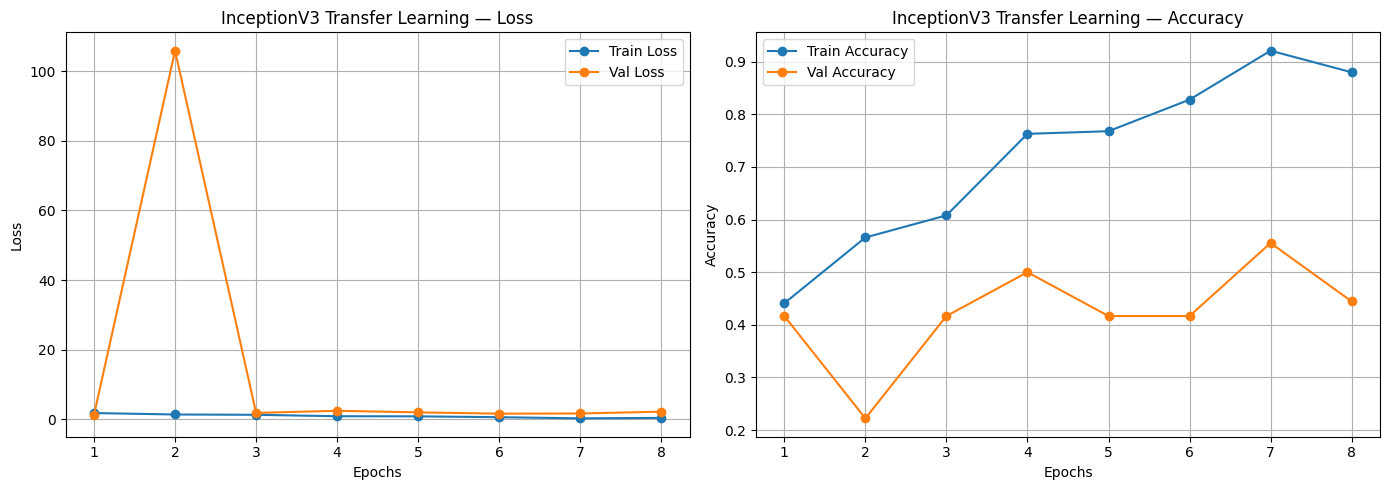

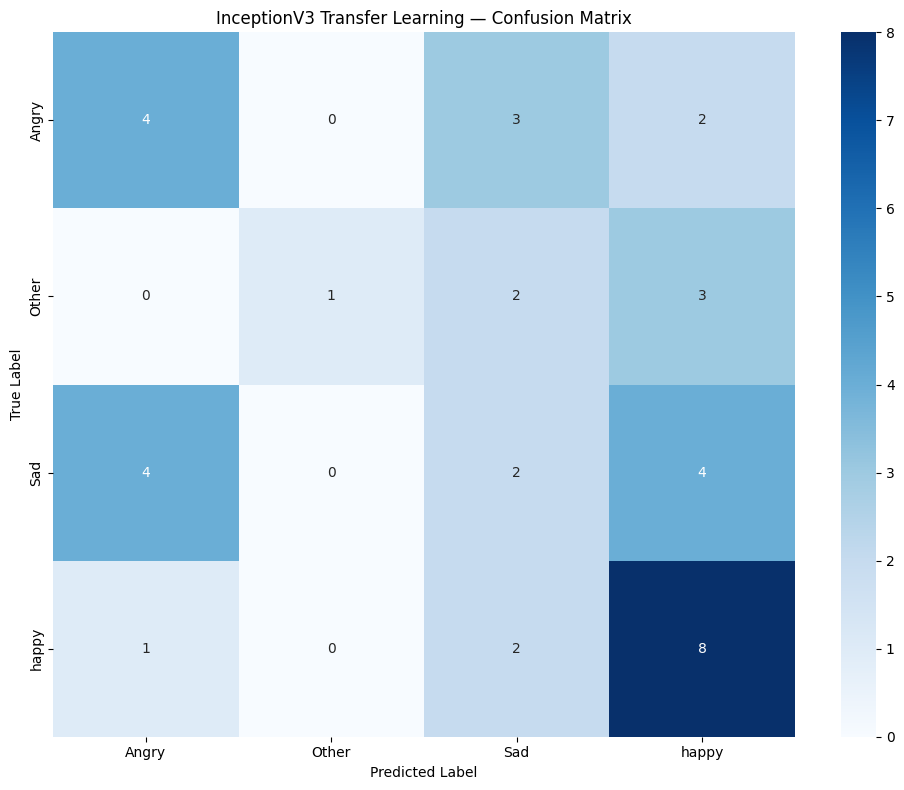

In [5]:
history_path = os.path.join(config.CHECKPOINT_DIR, "InceptionV3_TransferLearning_history.pt")

if os.path.exists(history_path):
    history = torch.load(history_path)

    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='o')
    plt.title('InceptionV3 Transfer Learning — Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(epochs_range, history['val_acc'],   label='Val Accuracy',   marker='o')
    plt.title('InceptionV3 Transfer Learning — Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title('InceptionV3 Transfer Learning — Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
else:
    print("History file not found. Run the training cell first.")